# MATH 616: Computational Linear Algebra
## Coding Lab — Iterative Methods: Jacobi, Gauss–Seidel, and SOR

This notebook is the coding companion to the *Iterative Methods for Linear Systems* lecture. We implement the three classical methods exactly as they appear on the slides, reproduce the $3\times 3$ worked example (in exact arithmetic first), and then ask the question that motivates the whole lecture: **when is iterating actually cheaper than Gaussian elimination?**

### Learning goals
By the end of the lab you should be able to:

- implement Jacobi, Gauss–Seidel, and SOR component by component, and check them against the slides;
- see the error shrink by a roughly constant factor per sweep, and see a method fail when the matrix is not suitable;
- write each sweep in vectorized form, so that timing experiments measure the algorithm rather than the Python interpreter;
- compare the cost of iteration with dense LU and with a sparse direct solver, counting both flops and seconds;
- explain why the number of sweeps grows with $n$ on PDE problems, and what that does to the total cost;
- recognize the cases where a direct method still wins: small or dense systems, many right-hand sides, one-dimensional problems.

Sections marked ✏️ are for you to edit and re-run. Timings depend on your machine, so expect your numbers to differ from the executed copy; the *trends* should not.

## 0. Imports and helpers

In [ ]:
import time
from fractions import Fraction
import numpy as np
import scipy.linalg as sla
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True, linewidth=110)
rng = np.random.default_rng(616)


def timed(f, *args, repeat=1, **kwargs):
    """Call f(*args, **kwargs) `repeat` times; return (result, best wall time in seconds)."""
    best = np.inf
    for _ in range(repeat):
        t0 = time.perf_counter()
        out = f(*args, **kwargs)
        best = min(best, time.perf_counter() - t0)
    return out, best


def rel_res(A, x, b):
    """Relative residual ||b - A x|| / ||b||."""
    return np.linalg.norm(b - A @ x) / np.linalg.norm(b)

# Part I. The three methods, as on the slides

## 1. The $3\times 3$ example

All three methods solve equation $i$ for unknown $x_i$:

$$x_i = \Big(b_i - \sum_{j<i} a_{ij}x_j - \sum_{j>i} a_{ij}x_j\Big)\Big/ a_{ii}.$$

They differ only in which values, old or freshly updated, go into the two sums. The running example is

$$\begin{bmatrix}10&1&1\\-1&10&1\\-1&-1&10\end{bmatrix}x=\begin{bmatrix}12\\10\\8\end{bmatrix},\qquad x^* = (1,1,1),\qquad x^{(0)}=0.$$

In [ ]:
A3 = np.array([[10., 1., 1.],
               [-1., 10., 1.],
               [-1., -1., 10.]])
b3 = np.array([12., 10., 8.])
x_star = np.ones(3)
x0 = np.zeros(3)
print("residual of x* :", b3 - A3 @ x_star)

residual of x* : [0. 0. 0.]


## 2. The slide functions

These are the three functions from the slides, unchanged. Each stops when two consecutive iterates agree to a relative tolerance and returns the solution together with the number of sweeps.

In [ ]:
def jacobi(A, b, x0, tol=1e-8, maxit=200):
    """Jacobi iteration for A x = b, starting from the guess x0."""
    n = len(b)
    x_old = x0.astype(float)
    for it in range(1, maxit + 1):
        x = np.empty(n)
        for i in range(n):
            s = A[i, :i] @ x_old[:i] + A[i, i+1:] @ x_old[i+1:]
            x[i] = (b[i] - s) / A[i, i]
        if np.linalg.norm(x - x_old) <= tol * max(1, np.linalg.norm(x)):
            return x, it
        x_old = x
    raise RuntimeError("Jacobi did not converge in maxit iterations")


def gauss_seidel(A, b, x0, tol=1e-8, maxit=200):
    """Gauss-Seidel iteration: new values are used as soon as they exist."""
    n = len(b)
    x = x0.astype(float).copy()
    for it in range(1, maxit + 1):
        x_old = x.copy()
        for i in range(n):
            # x[:i] already holds sweep k+1, x[i+1:] still holds sweep k
            s = A[i, :i] @ x[:i] + A[i, i+1:] @ x[i+1:]
            x[i] = (b[i] - s) / A[i, i]
        if np.linalg.norm(x - x_old) <= tol * max(1, np.linalg.norm(x)):
            return x, it
    raise RuntimeError("Gauss-Seidel did not converge in maxit iterations")


def sor(A, b, x0, omega, tol=1e-8, maxit=200):
    """SOR iteration with relaxation parameter omega; omega = 1 is Gauss-Seidel."""
    n = len(b)
    x = x0.astype(float).copy()
    for it in range(1, maxit + 1):
        x_old = x.copy()
        for i in range(n):
            s = A[i, :i] @ x[:i] + A[i, i+1:] @ x[i+1:]
            x_gs = (b[i] - s) / A[i, i]                 # Gauss-Seidel value
            x[i] = omega * x_gs + (1 - omega) * x_old[i]
        if np.linalg.norm(x - x_old) <= tol * max(1, np.linalg.norm(x)):
            return x, it
    raise RuntimeError("SOR did not converge in maxit iterations")


for name, (x, it) in [("Jacobi",          jacobi(A3, b3, x0, 1e-10)),
                      ("Gauss-Seidel",    gauss_seidel(A3, b3, x0, 1e-10)),
                      ("SOR, omega = 0.8", sor(A3, b3, x0, 0.8, 1e-10)),
                      ("SOR, omega = 1.1", sor(A3, b3, x0, 1.1, 1e-10))]:
    print(f"{name:17s} {it:3d} sweeps   x = {x}   max error = {np.abs(x - x_star).max():.1e}")

Jacobi             15 sweeps   x = [1. 1. 1.]   max error = 4.4e-12
Gauss-Seidel       10 sweeps   x = [1. 1. 1.]   max error = 6.0e-13
SOR, omega = 0.8   16 sweeps   x = [1. 1. 1.]   max error = 2.4e-11
SOR, omega = 1.1   16 sweeps   x = [1. 1. 1.]   max error = 1.7e-11


## 3. The worked example in exact arithmetic

The slides quote the first sweeps as fractions. A sweep only adds, multiplies, and divides, so running it on Python `Fraction`s reproduces those numbers exactly. The two helper functions below perform **one sweep** each and work for any number type.

Expected from the slides:

| | sweep 1 | sweep 2 |
|---|---|---|
| Jacobi | $(6/5,\ 1,\ 4/5)$ | $(51/50,\ 26/25,\ 51/50)$ |
| Gauss–Seidel | $(6/5,\ 28/25,\ 129/125)$ | |
| SOR, $\omega = 0.8$ | $(24/25,\ 548/625,\ 12296/15625)$ | |

In [ ]:
def jacobi_sweep(A, b, x):
    """One Jacobi sweep: every component from the old vector x."""
    n = len(b)
    return [(b[i] - sum(A[i][j] * x[j] for j in range(n) if j != i)) / A[i][i]
            for i in range(n)]


def sor_sweep(A, b, x, omega=1):
    """One SOR sweep (omega = 1: one Gauss-Seidel sweep). x is not modified."""
    n = len(b)
    x = list(x)
    for i in range(n):
        s = sum(A[i][j] * x[j] for j in range(n) if j != i)   # x[:i] is already new
        x[i] = omega * (b[i] - s) / A[i][i] + (1 - omega) * x[i]
    return x


def show(v):
    return "(" + ", ".join(str(t) for t in v) + ")"


Af = [[Fraction(int(v)) for v in row] for row in A3]
bf = [Fraction(int(v)) for v in b3]
zero = [Fraction(0)] * 3

x = zero
for k in range(1, 4):
    x = jacobi_sweep(Af, bf, x)
    print(f"Jacobi        x^({k}) = {show(x)}")
x = zero
for k in range(1, 3):
    x = sor_sweep(Af, bf, x, omega=1)
    print(f"Gauss-Seidel  x^({k}) = {show(x)}")
x = sor_sweep(Af, bf, zero, omega=Fraction(4, 5))
print(f"SOR 0.8       x^(1) = {show(x)}")

Jacobi        x^(1) = (6/5, 1, 4/5)
Jacobi        x^(2) = (51/50, 26/25, 51/50)
Jacobi        x^(3) = (497/500, 1, 503/500)
Gauss-Seidel  x^(1) = (6/5, 28/25, 129/125)
Gauss-Seidel  x^(2) = (1231/1250, 12441/12500, 124751/125000)
SOR 0.8       x^(1) = (24/25, 548/625, 12296/15625)


## 4. Watching the error

We now run a fixed number of sweeps in floating point and record the error $\|x^{(k)}-x^*\|_\infty$ after each one. The first table reproduces the two tables on the slides.

In [ ]:
def error_history(sweep, K, **kw):
    """Errors ||x^(k) - x*||_inf for k = 1..K, from x^(0) = 0, using a one-sweep function."""
    x, errs = x0.copy(), []
    for _ in range(K):
        x = np.array(sweep(A3, b3, x, **kw))
        errs.append(np.abs(x - x_star).max())
    return np.array(errs)


K = 30
hist = {"Jacobi":           error_history(jacobi_sweep, K),
        "Gauss-Seidel":     error_history(sor_sweep, K, omega=1.0),
        "SOR, omega = 0.8": error_history(sor_sweep, K, omega=0.8),
        "SOR, omega = 1.1": error_history(sor_sweep, K, omega=1.1)}

print(f"{'k':>3}" + "".join(f"{name:>18}" for name in hist))
for k in [1, 2, 3, 5, 10]:
    print(f"{k:>3}" + "".join(f"{h[k-1]:>18.1e}" for h in hist.values()))

  k            Jacobi      Gauss-Seidel  SOR, omega = 0.8  SOR, omega = 1.1
  1           2.0e-01           2.0e-01           2.1e-01           3.2e-01
  2           4.0e-02           1.5e-02           4.2e-02           7.7e-02
  3           6.0e-03           6.7e-04           7.6e-03           1.7e-02
  5           1.8e-04           1.8e-06           3.9e-04           7.0e-04
 10           3.2e-08           6.0e-13           1.7e-07           2.4e-07


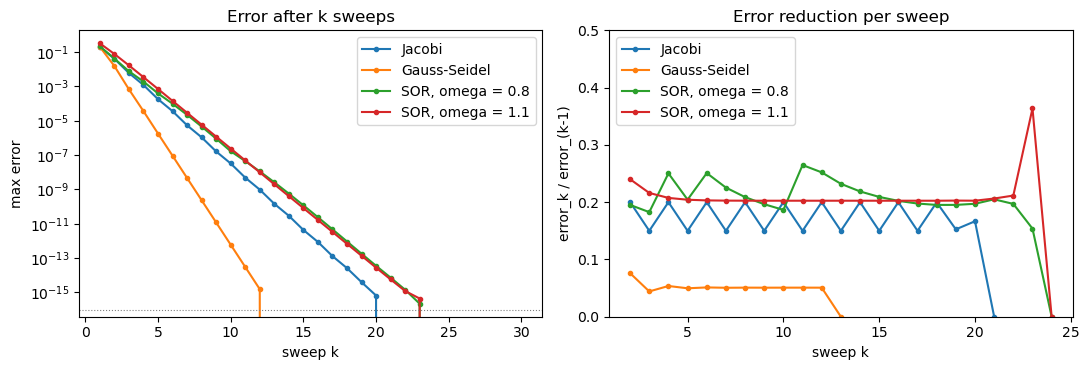

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for name, h in hist.items():
    ax[0].semilogy(range(1, K + 1), h, marker=".", label=name)
    with np.errstate(divide="ignore", invalid="ignore"):   # errors reach exactly 0 at the end
        ax[1].plot(range(2, K + 1), h[1:] / h[:-1], marker=".", label=name)
ax[0].set(xlabel="sweep k", ylabel="max error", title="Error after k sweeps")
ax[1].set(xlabel="sweep k", ylabel="error_k / error_(k-1)", title="Error reduction per sweep", ylim=(0, 0.5))
ax[0].axhline(1e-16, color="gray", lw=0.8, ls=":")
ax[0].legend(); ax[1].legend()
plt.tight_layout(); plt.show()

**Observe.** On a log scale every curve is (eventually) a straight line, so each sweep multiplies the error by a roughly constant factor (right panel, before round-off takes over around $10^{-16}$). For this system the factor is about $0.05$ for Gauss–Seidel and about $0.2$ for SOR with either $\omega$. Jacobi alternates between about $0.15$ and $0.2$, an average of about $0.17$ per sweep. The convergence part of the lecture names this factor (the *spectral radius* of the iteration matrix) and shows how to compute it in advance. For now, keep the rule of thumb:

$$\text{sweeps for } p \text{ digits} \;\approx\; \frac{p}{-\log_{10}(\text{reduction factor})}.$$

### ✏️ Your turn: choosing $\omega$
Neither $\omega = 0.8$ nor $\omega = 1.1$ beats Gauss–Seidel on this system. Scan $\omega$ and find out where the best value is. Edit the range and the tolerance, then re-run.

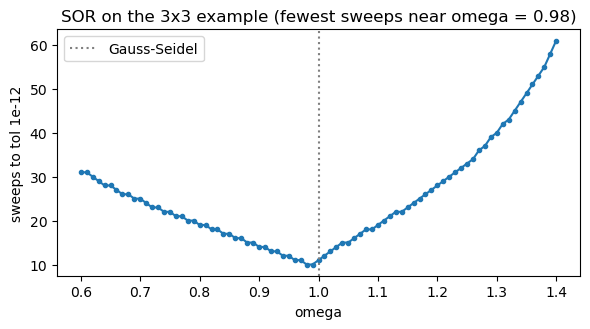

In [ ]:
omegas = np.linspace(0.6, 1.4, 81)          # <-- try other ranges
sweeps = [sor(A3, b3, x0, w, tol=1e-12, maxit=500)[1] for w in omegas]

best = omegas[int(np.argmin(sweeps))]
plt.figure(figsize=(6, 3.4))
plt.plot(omegas, sweeps, marker=".")
plt.axvline(1.0, color="gray", ls=":", label="Gauss-Seidel")
plt.xlabel("omega"); plt.ylabel("sweeps to tol 1e-12"); plt.legend()
plt.title(f"SOR on the 3x3 example (fewest sweeps near omega = {best:.2f})")
plt.tight_layout(); plt.show()

## 5. When the methods fail

Nothing so far guarantees convergence. Two small experiments show what can go wrong.

**(a) The order of the equations matters.** Swap the first two equations of the example. The solution is the same, but now the diagonal entries are $-1$ and $1$, small compared with the rest of their rows.

**(b) Jacobi and Gauss–Seidel need not agree.** The matrix below is symmetric positive definite. Gauss–Seidel converges on every such matrix (a theorem in the special-matrices part of the lecture), but Jacobi does not have to.

In [ ]:
def run_errors(sweep, A, b, xs, ks, **kw):
    x, out = np.zeros(len(b)), []
    for k in range(1, max(ks) + 1):
        x = np.array(sweep(A, b, x, **kw))
        if k in ks:
            out.append(np.abs(x - xs).max())
    return out


ks = [5, 10, 20, 40]
print("(a) swapped equations")
A_sw, b_sw = A3[[1, 0, 2]], b3[[1, 0, 2]]
print(A_sw)
for name, sw, kw in [("Jacobi", jacobi_sweep, {}), ("Gauss-Seidel", sor_sweep, {"omega": 1.0})]:
    errs = run_errors(sw, A_sw, b_sw, x_star, ks, **kw)
    print(f"  {name:13s}" + "".join(f"  k={k}: {e:8.1e}" for k, e in zip(ks, errs)))

print("\n(b) symmetric positive definite, a = 0.6")
a = 0.6
A_spd = np.array([[1, a, a], [a, 1, a], [a, a, 1]])
print("eigenvalues:", np.linalg.eigvalsh(A_spd))
b_spd = A_spd @ x_star
for name, sw, kw in [("Jacobi", jacobi_sweep, {}), ("Gauss-Seidel", sor_sweep, {"omega": 1.0})]:
    errs = run_errors(sw, A_spd, b_spd, x_star, ks, **kw)
    print(f"  {name:13s}" + "".join(f"  k={k}: {e:8.1e}" for k, e in zip(ks, errs)))

(a) swapped equations
[[-1. 10.  1.]
 [10.  1.  1.]
 [-1. -1. 10.]]
  Jacobi         k=5:  1.1e+05  k=10:  1.1e+10  k=20:  1.1e+20  k=40:  1.1e+40
  Gauss-Seidel   k=5:  1.2e+10  k=10:  1.2e+20  k=20:  1.3e+40  k=40:  1.6e+80

(b) symmetric positive definite, a = 0.6
eigenvalues: [0.4 0.4 2.2]
  Jacobi         k=5:  2.5e+00  k=10:  6.2e+00  k=20:  3.8e+01  k=40:  1.5e+03
  Gauss-Seidel   k=5:  4.4e-02  k=10:  1.1e-03  k=20:  3.3e-07  k=40:  1.0e-13


**Observe.** In (a) both methods blow up: always arrange the equations so that the diagonal is as large as possible. In (b) Jacobi's error grows by about a factor $1.2$ per sweep while Gauss–Seidel converges. The original ordering in (a) is *strictly diagonally dominant* ($|a_{ii}| > \sum_{j\ne i}|a_{ij}|$), and for such matrices both methods always converge, as the lecture proves later.

# Part II. Making a sweep fast

The slide functions loop over rows in Python. That is fine for understanding, but a timing experiment with them would measure the interpreter, not the method. Before comparing costs we write each sweep with whole-array operations.

## 6. Jacobi in one line

Adding and subtracting $a_{ii}x_i$ in the Jacobi formula gives the **residual form**

$$x^{(k+1)} = x^{(k)} + D^{-1}\big(b - A x^{(k)}\big),\qquad D = \operatorname{diag}(a_{11},\dots,a_{nn}).$$

One sweep is one product with $A$ plus $n$ divisions, about $2\,\mathrm{nnz}(A)$ flops, where $\mathrm{nnz}(A)$ is the number of nonzero entries. The same code works for a dense NumPy array and for a SciPy sparse matrix.

## 7. Gauss–Seidel and SOR as one triangular solve

Move every *new* value in the SOR formula to the left-hand side:

$$a_{ii}x_i^{(k+1)} + \omega\sum_{j<i}a_{ij}x_j^{(k+1)} \;=\; \omega\Big(b_i - \sum_{j>i}a_{ij}x_j^{(k)}\Big) + (1-\omega)\,a_{ii}x_i^{(k)} .$$

The left side is a lower-triangular matrix times $x^{(k+1)}$, so **one sweep is one forward substitution**: about $n^2$ flops for the strict upper product and $n^2$ for the solve on a dense matrix. (The matrix-formulation part of the lecture writes this with $A = D - L - U$.)

## 8. A common driver

All experiments below use one driver that stops on the **relative residual** $\|b - Ax^{(k)}\|/\|b\|$. The residual says how well the equations are satisfied, and unlike the step $\|x^{(k+1)}-x^{(k)}\|$ it does not become small just because the method is crawling (Exercise 2 shows the trap). Computing it costs one extra product with $A$ per sweep, for every method alike.

In [ ]:
def iterate(sweep, A, b, x0, tol=1e-10, maxit=200_000):
    """Apply x <- sweep(x) until ||b - A x|| <= tol ||b||. Returns (x, number of sweeps)."""
    x = np.array(x0, dtype=float)
    nb = np.linalg.norm(b)
    for k in range(maxit + 1):
        if np.linalg.norm(b - A @ x) <= tol * nb:
            return x, k
        x = sweep(x)
    raise RuntimeError(f"no convergence in {maxit} sweeps")


def make_jacobi(A, b):
    """Vectorized Jacobi sweep (dense or sparse A): x + D^{-1}(b - A x)."""
    d = A.diagonal()
    return lambda x: x + (b - A @ x) / d


def make_sor(A, b, omega=1.0):
    """Vectorized SOR sweep for a dense A (omega = 1: Gauss-Seidel), one forward substitution."""
    d = np.diag(A).copy()
    T = np.diag(d) + omega * np.tril(A, -1)      # lower triangle that multiplies the new values
    Up = np.triu(A, 1)                           # strict upper triangle, old values
    return lambda x: sla.solve_triangular(T, omega * (b - Up @ x) + (1 - omega) * d * x,
                                          lower=True, check_finite=False)


# check: five vectorized sweeps agree with five sweeps of the loop versions
for name, fast, slow in [("Jacobi",          make_jacobi(A3, b3),     lambda x: jacobi_sweep(A3, b3, x)),
                         ("Gauss-Seidel",    make_sor(A3, b3, 1.0),   lambda x: sor_sweep(A3, b3, x, 1.0)),
                         ("SOR, omega = 1.1", make_sor(A3, b3, 1.1),  lambda x: sor_sweep(A3, b3, x, 1.1))]:
    xf, xs = x0.copy(), x0.copy()
    for _ in range(5):
        xf, xs = fast(xf), np.array(slow(xs))
    print(f"{name:17s} max difference after 5 sweeps: {np.abs(xf - xs).max():.1e}")

Jacobi            max difference after 5 sweeps: 4.4e-16
Gauss-Seidel      max difference after 5 sweeps: 0.0e+00
SOR, omega = 1.1  max difference after 5 sweeps: 2.2e-16


**How much does vectorizing buy?** Time one sweep of each version on a dense, strictly diagonally dominant matrix with $n = 400$. The helper `make_sdd` builds such a matrix: positive off-diagonal entries, and each diagonal entry $1+\delta$ times the rest of its row.

In [ ]:
def make_sdd(n, delta=0.5):
    """Dense strictly diagonally dominant matrix: |a_ii| = (1 + delta) * sum_{j != i} |a_ij|."""
    A = rng.uniform(0, 1, (n, n))
    np.fill_diagonal(A, 0.0)
    A[np.diag_indices(n)] = (1 + delta) * A.sum(axis=1)
    return A


n = 400
A = make_sdd(n)
b = A @ np.ones(n)
x = np.zeros(n)

def one_loop_sweep():
    """One sweep of the slide's row loop (maxit = 1, so the function raises after one sweep)."""
    try:
        gauss_seidel(A, b, x, tol=0.0, maxit=1)
    except RuntimeError:
        pass


_, t_loop = timed(one_loop_sweep, repeat=3)
gs = make_sor(A, b, 1.0)
_, t_vec = timed(gs, x, repeat=20)
jac = make_jacobi(A, b)
_, t_jac = timed(jac, x, repeat=20)
print(f"one Gauss-Seidel sweep, Python row loop : {1e3 * t_loop:8.3f} ms")
print(f"one Gauss-Seidel sweep, triangular solve: {1e3 * t_vec:8.3f} ms   ({t_loop / t_vec:.0f}x faster)")
print(f"one Jacobi sweep, vectorized            : {1e3 * t_jac:8.3f} ms")

one Gauss-Seidel sweep, Python row loop :    0.634 ms
one Gauss-Seidel sweep, triangular solve:    0.183 ms   (3x faster)
one Jacobi sweep, vectorized            :    0.014 ms


The same arithmetic runs one to two orders of magnitude faster without the Python loop. From here on every timing uses the vectorized sweeps, and LAPACK's compiled `solve` for the direct method. Even so, compiled LAPACK is better tuned than our sweeps, which is why the flop counts are reported next to the seconds.

# Part III. Is iterating cheaper than elimination?

## 9. The flop model

| Method | Cost |
|---|---|
| LU / Gaussian elimination, dense | $\tfrac{2}{3}n^3$ to factor, then $2n^2$ per right-hand side |
| One iterative sweep | about $2\,\mathrm{nnz}(A)$: that is $2n^2$ dense, about $10n$ for a 5-point stencil |
| Iterative method, $k$ sweeps | $k \times$ (cost of one sweep) |

So iteration wins on a **dense** matrix only if it needs fewer than about $n/3$ sweeps, and on a **sparse** matrix with $5$ nonzeros per row only if it needs fewer than about $n^2/15$ sweeps. The break-even counts are generous, so the real question is how the number of sweeps $k$ behaves as $n$ grows.

In [ ]:
print(f"{'n':>10} {'dense LU flops':>16} {'break-even sweeps, dense':>26} {'break-even sweeps, 5 nnz/row':>30}")
for n in [1e2, 1e3, 1e4, 1e6]:
    lu = 2 * n**3 / 3
    print(f"{n:>10.0e} {lu:>16.1e} {lu / (2 * n**2):>26.1e} {lu / (10 * n):>30.1e}")

         n   dense LU flops   break-even sweeps, dense   break-even sweeps, 5 nnz/row
     1e+02          6.7e+05                    3.3e+01                        6.7e+02
     1e+03          6.7e+08                    3.3e+02                        6.7e+04
     1e+04          6.7e+11                    3.3e+03                        6.7e+06
     1e+06          6.7e+17                    3.3e+05                        6.7e+10


## 10. Experiment A: dense, strictly diagonally dominant matrices

With $\delta = 0.5$ every row of `make_sdd` has the same dominance ratio, so the reduction factor per sweep does not depend on $n$. The number of sweeps should therefore stay **constant** as $n$ grows, making the iterative cost $O(n^2)$ against $O(n^3)$ for LU.

In [ ]:
tol = 1e-10
rows = []
for n in [250, 500, 1000, 2000, 3000]:
    A = make_sdd(n)
    x_true = rng.standard_normal(n)
    b = A @ x_true
    x_lu, t_lu = timed(np.linalg.solve, A, b, repeat=3)
    (x_j, k_j), t_j = timed(iterate, make_jacobi(A, b), A, b, np.zeros(n), tol)
    (x_g, k_g), t_g = timed(iterate, make_sor(A, b, 1.0), A, b, np.zeros(n), tol)
    rows.append((n, t_lu, k_j, t_j, k_g, t_g))
    print(f"n = {n:5d}   LU {t_lu:7.3f} s | Jacobi {k_j:3d} sweeps {t_j:7.3f} s | "
          f"Gauss-Seidel {k_g:3d} sweeps {t_g:7.3f} s | errors "
          f"{np.abs(x_lu - x_true).max():.0e} {np.abs(x_j - x_true).max():.0e} {np.abs(x_g - x_true).max():.0e}")
rows = np.array(rows)

n =   250   LU   0.001 s | Jacobi  53 sweeps   0.001 s | Gauss-Seidel  12 sweeps   0.000 s | errors 3e-15 5e-11 6e-11
n =   500   LU   0.002 s | Jacobi  52 sweeps   0.001 s | Gauss-Seidel  12 sweeps   0.001 s | errors 6e-15 4e-11 4e-11


n =  1000   LU   0.011 s | Jacobi  52 sweeps   0.013 s | Gauss-Seidel  12 sweeps   0.006 s | errors 8e-15 5e-11 4e-11


n =  2000   LU   0.038 s | Jacobi  48 sweeps   0.026 s | Gauss-Seidel  11 sweeps   0.020 s | errors 1e-14 5e-11 1e-10


n =  3000   LU   0.118 s | Jacobi  47 sweeps   0.265 s | Gauss-Seidel  11 sweeps   0.072 s | errors 2e-14 4e-11 4e-11


     n   LU flops  Jacobi flops   GS flops  LU / Jacobi   LU / GS
   250    1.0e+07       6.6e+06    1.5e+06          1.6       6.9
   500    8.3e+07       2.6e+07    6.0e+06          3.2      13.9
  1000    6.7e+08       1.0e+08    2.4e+07          6.4      27.8
  2000    5.3e+09       3.8e+08    8.8e+07         13.9      60.6
  3000    1.8e+10       8.5e+08    2.0e+08         21.3      90.9


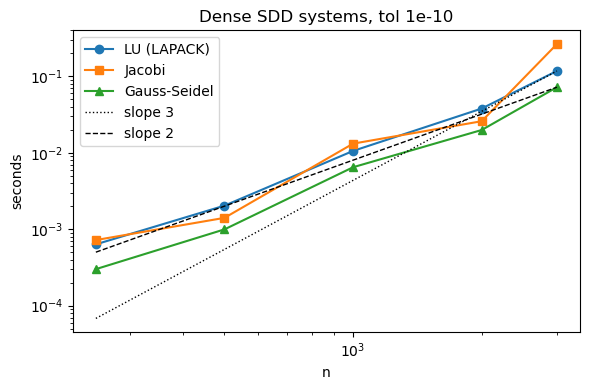

In [ ]:
n_, t_lu, k_j, t_j, k_g, t_g = rows.T
print(f"{'n':>6} {'LU flops':>10} {'Jacobi flops':>13} {'GS flops':>10} {'LU / Jacobi':>12} {'LU / GS':>9}")
for n, kj, kg in zip(n_, k_j, k_g):
    lu, fj, fg = 2 * n**3 / 3, kj * 2 * n**2, kg * 2 * n**2
    print(f"{n:>6.0f} {lu:>10.1e} {fj:>13.1e} {fg:>10.1e} {lu / fj:>12.1f} {lu / fg:>9.1f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(n_, t_lu, "o-", label="LU (LAPACK)")
ax.loglog(n_, t_j, "s-", label="Jacobi")
ax.loglog(n_, t_g, "^-", label="Gauss-Seidel")
ax.loglog(n_, t_lu[-1] * (n_ / n_[-1])**3, "k:", lw=1, label="slope 3")
ax.loglog(n_, t_g[-1] * (n_ / n_[-1])**2, "k--", lw=1, label="slope 2")
ax.set(xlabel="n", ylabel="seconds", title="Dense SDD systems, tol 1e-10")
ax.legend(); plt.tight_layout(); plt.show()

**Observe.**

- The sweep counts do not grow with $n$ (they even drop slightly), so the iterative flop count grows like $n^2$ and the LU count like $n^3$. The flop ratio LU / iteration grows linearly in $n$.
- In *seconds* LU does far better than its flop count suggests. LAPACK's factorization is built from matrix–matrix products, which reuse each number fetched from memory many times. A sweep is a matrix–vector product, which reads all $n^2$ entries to do $2n^2$ flops and is limited by memory speed. In this run Jacobi does about $20$ times fewer flops than LU at $n = 3000$ and is still slower. Gauss–Seidel, with four times fewer sweeps, is ahead. The crossover in time comes at a much larger $n$ than the flop model predicts, but the slopes decide the race eventually.
- Constant sweep counts on a dense matrix are the exception, not the rule: they rely on strong diagonal dominance that does not weaken as $n$ grows.

## 11. Experiment B: many right-hand sides

An LU factorization is paid for once and then reused at $2n^2$ per right-hand side. An iterative method starts over for every new $b$. Here $m$ right-hand sides arrive one at a time, as in the factorization lab.

In [ ]:
n = 2000
A = make_sdd(n)
lu_piv, t_fact = timed(sla.lu_factor, A)
print(f"n = {n}, LU factorization: {t_fact:.3f} s (paid once)\n")
print(f"{'m':>4} {'LU total (s)':>13} {'Jacobi total (s)':>17} {'GS total (s)':>13}")
for m in [1, 5, 20, 50]:
    B = rng.standard_normal((n, m))
    t0 = time.perf_counter()
    for j in range(m):
        sla.lu_solve(lu_piv, B[:, j])
    t_lu = t_fact + time.perf_counter() - t0
    t0 = time.perf_counter()
    for j in range(m):
        iterate(make_jacobi(A, B[:, j]), A, B[:, j], np.zeros(n), 1e-10)
    t_j = time.perf_counter() - t0
    t0 = time.perf_counter()
    for j in range(m):
        iterate(make_sor(A, B[:, j], 1.0), A, B[:, j], np.zeros(n), 1e-10)
    t_g = time.perf_counter() - t0
    print(f"{m:>4} {t_lu:>13.3f} {t_j:>17.3f} {t_g:>13.3f}")

n = 2000, LU factorization: 0.157 s (paid once)

   m  LU total (s)  Jacobi total (s)  GS total (s)
   1         0.158             0.051         0.041


   5         0.162             0.223         0.203


  20         0.174             1.030         0.983


  50         0.225             2.560         2.343


**Observe.** The LU column barely moves with $m$: after the factorization each solve is two triangular substitutions. The iterative columns grow linearly in $m$. With $k$ sweeps per solve, the flop model puts the break-even at roughly $m \approx n / (3k)$ right-hand sides, about $14$ here for Jacobi. In seconds LU wins already for a handful of right-hand sides, for the same memory-speed reason as in Experiment A. (`make_sor` also rebuilds its triangular matrices for each $b$ here, which adds a little to the Gauss–Seidel column. Building them once is Exercise 6.)

## 12. Experiment C: a sparse PDE problem, where iteration is meant to shine

The 5-point discretization of $-\Delta u = f$ on the unit square, with $N$ interior points per direction and $h = 1/(N+1)$, gives a system with $n = N^2$ unknowns:

$$4u_{ij} - u_{i-1,j} - u_{i+1,j} - u_{i,j-1} - u_{i,j+1} = h^2 f_{ij}.$$

The matrix has at most $5$ nonzeros per row, so a sweep costs $O(n)$, while dense LU costs $O(n^3) = O(N^6)$. We compare four approaches:

- **dense LU** on `A.toarray()` (only for small $N$; at $N = 128$ the dense matrix alone would take 2 GB);
- **sparse direct** `scipy.sparse.linalg.spsolve`, which reorders the unknowns to limit fill-in;
- **Jacobi, Gauss–Seidel, and SOR**, with sweeps written directly on the $N\times N$ grid.

For SOR we use $\omega_{\mathrm{opt}} = 2/(1+\sin\pi h)$. The special-matrices part of the lecture derives this formula; here we simply use it.

**A note on ordering.** A Gauss–Seidel sweep depends on the order in which the unknowns are visited (the slides point this out). On the grid it is natural to update all "red" points $(i+j$ even$)$ first and then all "black" points. Each half-sweep is then a single vectorized operation, because red points only have black neighbours. In the code the red points are the two "quarters" of the grid with both indices odd or both even, so each update is a strided slice of the array. This *red–black* ordering is still Gauss–Seidel, and the next cell checks that it needs about as many sweeps as the row-by-row ordering of the slides.

In [ ]:
def poisson2d(N):
    """Sparse 5-point Laplacian (times h^2) on an N x N grid, row-major ordering."""
    T = sp.diags([-1.0, 2.0, -1.0], [-1, 0, 1], shape=(N, N))
    I = sp.identity(N)
    return (sp.kron(I, T) + sp.kron(T, I)).tocsr()


def apply_A_grid(U):
    """A u on the grid; U is (N+2) x (N+2) with a zero boundary layer."""
    return (4 * U[1:-1, 1:-1] - U[:-2, 1:-1] - U[2:, 1:-1] - U[1:-1, :-2] - U[1:-1, 2:])


def jacobi_grid(Bg, tol, maxit=500_000):
    """Jacobi on the grid. Bg = h^2 f on the N x N interior. Returns (U interior, sweeps)."""
    N = Bg.shape[0]
    U = np.zeros((N + 2, N + 2))
    nb = np.linalg.norm(Bg)
    for k in range(maxit + 1):
        R = Bg - apply_A_grid(U)
        if np.linalg.norm(R) <= tol * nb:
            return U[1:-1, 1:-1].copy(), k
        U[1:-1, 1:-1] += R / 4                      # x + D^{-1} r
    raise RuntimeError("Jacobi: no convergence")


def _update_quarter(U, Bg, omega, i0, j0):
    """SOR update of the grid points (i0 + 2s, j0 + 2t) of the padded array U, i0, j0 in {1, 2}."""
    N = Bg.shape[0]
    rows, cols = slice(i0, N + 1, 2), slice(j0, N + 1, 2)
    nbrs = (U[i0 - 1:N:2, cols] + U[i0 + 1:N + 2:2, cols]
            + U[rows, j0 - 1:N:2] + U[rows, j0 + 1:N + 2:2])
    x_gs = (Bg[i0 - 1::2, j0 - 1::2] + nbrs) / 4
    U[rows, cols] = omega * x_gs + (1 - omega) * U[rows, cols]


def rb_sor_grid(Bg, omega, tol, maxit=500_000):
    """Red-black SOR on the grid (omega = 1: red-black Gauss-Seidel). Returns (U interior, sweeps)."""
    N = Bg.shape[0]
    U = np.zeros((N + 2, N + 2))
    nb = np.linalg.norm(Bg)
    for k in range(maxit + 1):
        if np.linalg.norm(Bg - apply_A_grid(U)) <= tol * nb:
            return U[1:-1, 1:-1].copy(), k
        for i0, j0 in [(1, 1), (2, 2), (1, 2), (2, 1)]:   # the two red quarters, then the two black
            _update_quarter(U, Bg, omega, i0, j0)
    raise RuntimeError("SOR: no convergence")


def rhs_grid(N):
    h = 1 / (N + 1)
    t = np.linspace(h, 1 - h, N)
    X, Y = np.meshgrid(t, t, indexing="ij")
    return h**2 * 2 * np.pi**2 * np.sin(np.pi * X) * np.sin(np.pi * Y)   # exact u = sin(pi x) sin(pi y)


# sanity checks at N = 16
N, tol = 16, 1e-6
A, Bg = poisson2d(N), rhs_grid(N)
b = Bg.ravel()
x_direct = spla.spsolve(A.tocsc(), b)
Uj, kj = jacobi_grid(Bg, tol)
_, kj_mat = iterate(make_jacobi(A, b), A, b, np.zeros(N * N), tol)
Ug, kg_rb = rb_sor_grid(Bg, 1.0, tol)
_, kg_nat = iterate(make_sor(A.toarray(), b, 1.0), A, b, np.zeros(N * N), tol)
print(f"Jacobi: grid version {kj} sweeps, matrix version {kj_mat} sweeps")
print(f"Gauss-Seidel: red-black {kg_rb} sweeps, row-by-row ordering {kg_nat} sweeps")
print(f"difference from sparse direct solution: Jacobi {np.abs(Uj.ravel() - x_direct).max():.1e}, "
      f"GS {np.abs(Ug.ravel() - x_direct).max():.1e}")

Jacobi: grid version 805 sweeps, matrix version 805 sweeps


Gauss-Seidel: red-black 413 sweeps, row-by-row ordering 404 sweeps
difference from sparse direct solution: Jacobi 9.9e-07, GS 7.0e-07


Now the main experiment. Jacobi and Gauss–Seidel are only run up to $N = 128$ and dense LU up to $N = 64$, because beyond that they take too long or too much memory. Those cells are left blank in the table. The tolerance $10^{-6}$ is reasonable here, since the discretization error of the 5-point scheme is already about $h^2 \approx 10^{-4}$–$10^{-5}$.

In [ ]:
tol = 1e-6
Ns = [16, 32, 64, 128, 256]
res = {key: {} for key in ["dense", "sparse", "J", "GS", "SOR"]}
fill = {}

for N in Ns:
    n, h = N * N, 1 / (N + 1)
    A, Bg = poisson2d(N), rhs_grid(N)
    b = Bg.ravel()
    if N <= 64:
        _, t = timed(np.linalg.solve, A.toarray(), b, repeat=3)
        res["dense"][N] = (None, t)
    _, t = timed(spla.spsolve, A.tocsc(), b, repeat=3)
    res["sparse"][N] = (None, t)
    lu = spla.splu(A.tocsc())
    fill[N] = (A.nnz, lu.L.nnz + lu.U.nnz)
    if N <= 128:
        (_, k), t = timed(jacobi_grid, Bg, tol); res["J"][N] = (k, t)
        (_, k), t = timed(rb_sor_grid, Bg, 1.0, tol); res["GS"][N] = (k, t)
    w = 2 / (1 + np.sin(np.pi * h))
    (_, k), t = timed(rb_sor_grid, Bg, w, tol); res["SOR"][N] = (k, t)

def cell(d, N, sweeps=True):
    """Format one table entry: 'sweeps  seconds' for iterations, 'seconds' for direct solvers."""
    if N not in d:
        return f"{'—':>9}{'':>8}" if sweeps else f"{'—':>9}"
    k, t = d[N]
    return f"{k:>9d}{t:>8.3f}" if sweeps else f"{t:>9.3f}"

print(f"{'N':>4} {'n':>7} | {'dense LU':>9} {'sparse':>9} | {'Jacobi':>9}{'(s)':>8} | {'GS':>9}{'(s)':>8} | {'SOR':>9}{'(s)':>8}")
print(f"{'':>4} {'':>7} | {'(s)':>9} {'(s)':>9} | {'sweeps':>9}{'':>8} | {'sweeps':>9}{'':>8} | {'sweeps':>9}{'':>8}")
for N in Ns:
    print(f"{N:>4} {N*N:>7} | {cell(res['dense'], N, False)} {cell(res['sparse'], N, False)} | "
          f"{cell(res['J'], N)} | {cell(res['GS'], N)} | {cell(res['SOR'], N)}")

   N       n |  dense LU    sparse |    Jacobi     (s) |        GS     (s) |       SOR     (s)
             |       (s)       (s) |    sweeps         |    sweeps         |    sweeps        
  16     256 |     0.001     0.000 |       805   0.028 |       413   0.048 |        52   0.003
  32    1024 |     0.014     0.001 |      3045   0.035 |      1561   0.067 |       105   0.004
  64    4096 |     0.414     0.006 |     11824   0.315 |      6061   0.381 |       213   0.013
 128   16384 |         —     0.052 |     46584   3.589 |     23877   3.875 |       437   0.067
 256   65536 |         —     0.495 |         —         |         —         |       901   0.554


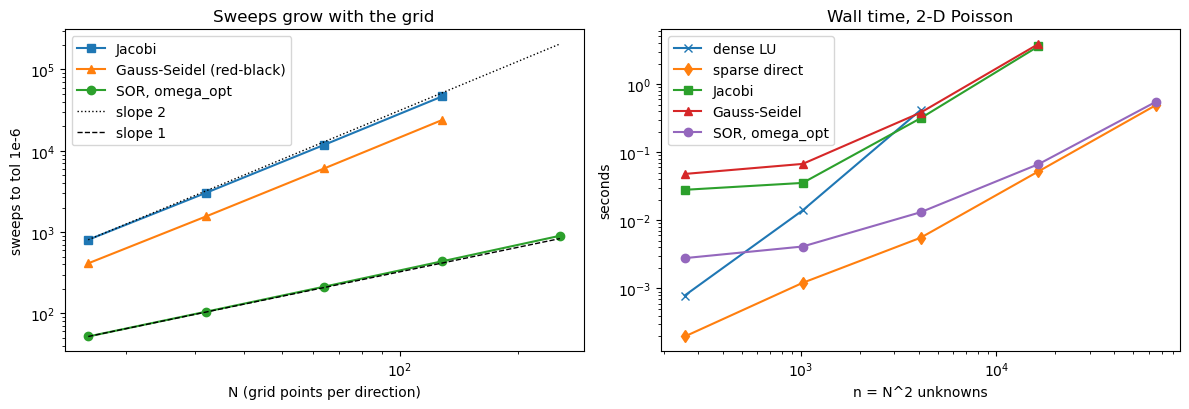

   N    nnz(A)   nnz(L)+nnz(U)  fill factor
  16      1216            5450          4.5
  32      4992           37334          7.5
  64     20224          220624         10.9
 128     81408         1221240         15.0
 256    326656         6242574         19.1


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for key, label, mk in [("J", "Jacobi", "s-"), ("GS", "Gauss-Seidel (red-black)", "^-"), ("SOR", "SOR, omega_opt", "o-")]:
    Nk = sorted(res[key]); ks = [res[key][N][0] for N in Nk]
    ax[0].loglog(Nk, ks, mk, label=label)
Nr = np.array(Ns, float)
ax[0].loglog(Nr, res["J"][16][0] * (Nr / 16)**2, "k:", lw=1, label="slope 2")
ax[0].loglog(Nr, res["SOR"][16][0] * (Nr / 16), "k--", lw=1, label="slope 1")
ax[0].set(xlabel="N (grid points per direction)", ylabel="sweeps to tol 1e-6", title="Sweeps grow with the grid")
ax[0].legend()

for key, label, mk in [("dense", "dense LU", "x-"), ("sparse", "sparse direct", "d-"), ("J", "Jacobi", "s-"),
                       ("GS", "Gauss-Seidel", "^-"), ("SOR", "SOR, omega_opt", "o-")]:
    Nk = sorted(res[key]); ts = [res[key][N][1] for N in Nk]
    ax[1].loglog([N * N for N in Nk], ts, mk, label=label)
ax[1].set(xlabel="n = N^2 unknowns", ylabel="seconds", title="Wall time, 2-D Poisson")
ax[1].legend(); plt.tight_layout(); plt.show()

print(f"{'N':>4} {'nnz(A)':>9} {'nnz(L)+nnz(U)':>15} {'fill factor':>12}")
for N, (a, f) in fill.items():
    print(f"{N:>4} {a:>9d} {f:>15d} {f / a:>12.1f}")

**Observe.**

- **The sweep count grows with the grid.** Doubling $N$ multiplies the Jacobi and Gauss–Seidel sweeps by about $4$ (slope $2$ in $N$, so about $n$ sweeps) and the SOR sweeps by about $2$ (slope $1$, so about $\sqrt n$). Gauss–Seidel needs half the sweeps of Jacobi at every size.
- **Total cost.** Sweeps times $O(n)$ per sweep gives about $O(n^2)$ for Jacobi and Gauss–Seidel and $O(n^{1.5})$ for SOR with the optimal $\omega$, against $O(n^3)$ for dense LU. Dense LU is already out of the race at $N = 64$.
- **Seconds versus sweeps.** A Gauss–Seidel sweep does the same arithmetic as a Jacobi sweep, but our red–black version touches the array in four strided pieces, so in seconds it does not cash in its factor-two advantage in sweeps. Compare methods by sweeps first and by seconds second.
- **Sparse direct keeps pace with SOR.** With a good ordering it costs roughly $O(n^{1.5})$ in 2-D, the same growth as SOR, and it runs compiled code, so the two are within a small factor of each other in this table. The price is memory: the fill table shows $L$ and $U$ holding many times more nonzeros than $A$, and that ratio keeps growing with $N$. In 3-D the fill gets much worse (Exercise 4), and that is where iterative methods take over.

### Extrapolating to $n = 10^6$

For this model problem the reduction factors per sweep are known in closed form (the convergence part of the lecture shows how): $\cos\pi h$ for Jacobi, $\cos^2\pi h$ for Gauss–Seidel, and $\omega_{\mathrm{opt}} - 1 \approx 1 - 2\pi h$ for SOR. That predicts the sweep counts for any $N$. The next cell first compares the prediction with the measurements, then extrapolates to $N = 1000$, i.e. a million unknowns, the size quoted at the start of the lecture.

In [ ]:
def predicted_sweeps(N, tol=1e-6):
    h = 1 / (N + 1)
    rJ = np.cos(np.pi * h)
    rS = 2 / (1 + np.sin(np.pi * h)) - 1
    p = np.log(1 / tol)
    return p / -np.log(rJ), p / -np.log(rJ**2), p / -np.log(rS)

print(f"{'N':>4} {'Jacobi meas/pred':>18} {'GS meas/pred':>16} {'SOR meas/pred':>16}")
for N in Ns:
    pj, pg, ps = predicted_sweeps(N)
    mj = res["J"].get(N, (np.nan,))[0]; mg = res["GS"].get(N, (np.nan,))[0]; ms = res["SOR"][N][0]
    print(f"{N:>4} {mj!s:>8} / {pj:>7.0f} {mg!s:>7} / {pg:>6.0f} {ms!s:>7} / {ps:>6.0f}")

N = 1000; n = N * N
pj, pg, ps = predicted_sweeps(N)
flops_sweep = 10 * n
print(f"\nn = {n:.0e} unknowns, about {flops_sweep:.0e} flops per sweep")
print(f"{'method':>14} {'sweeps':>10} {'flops':>10} {'time at 1e12 flop/s':>21}")
for name, k in [("Jacobi", pj), ("Gauss-Seidel", pg), ("SOR, omega_opt", ps)]:
    print(f"{name:>14} {k:>10.2e} {k * flops_sweep:>10.1e} {k * flops_sweep / 1e12:>19.2e} s")
corr = res["SOR"][Ns[-1]][0] / predicted_sweeps(Ns[-1])[2]
print(f"{'SOR, corrected':>14} {ps * corr:>10.2e} {ps * corr * flops_sweep:>10.1e} "
      f"{ps * corr * flops_sweep / 1e12:>19.2e} s   (measured factor {corr:.2f})")
lu = 2 * n**3 / 3
print(f"{'dense LU':>14} {'—':>10} {lu:>10.1e} {lu / 1e12:>19.2e} s  (about {lu / 1e12 / 86400:.0f} days)")

   N   Jacobi meas/pred     GS meas/pred    SOR meas/pred
  16      805 /     804     413 /    402      52 /     37
  32     3045 /    3044    1561 /   1522     105 /     72
  64    11824 /   11824    6061 /   5912     213 /    143
 128    46584 /   46584   23877 /  23292     437 /    284
 256      nan /  184907     nan /  92453     901 /    565

n = 1e+06 unknowns, about 1e+07 flops per sweep
        method     sweeps      flops   time at 1e12 flop/s
        Jacobi   2.81e+06    2.8e+13            2.81e+01 s
  Gauss-Seidel   1.40e+06    1.4e+13            1.40e+01 s
SOR, omega_opt   2.20e+03    2.2e+10            2.20e-02 s
SOR, corrected   3.51e+03    3.5e+10            3.51e-02 s   (measured factor 1.59)
      dense LU          —    6.7e+17            6.67e+05 s  (about 8 days)


**Observe.** The Jacobi prediction is essentially exact and Gauss–Seidel is within a few percent. SOR at $\omega_{\mathrm{opt}}$ needs about $1.6$ times the predicted sweeps at every $N$. The reason is special to the optimal $\omega$: there the iteration matrix is not diagonalizable, and the error behaves like $k\,\rho^k$ instead of $\rho^k$. The growth with $N$ (doubling when $N$ doubles) is still exactly as predicted, so the last line of the table corrects the SOR count by the measured factor.

At a million unknowns the ranking is stark: dense elimination needs over a week, Jacobi tens of seconds, and SOR with a good $\omega$ a fraction of a second, all on the same idealized teraflop machine.

## 13. A warning from one dimension

The same experiment in 1-D, $-u'' = f$ with $N$ points, gives a *tridiagonal* matrix. The tridiagonal algorithm from the factorization lecture solves it in $O(N)$ flops. Jacobi's reduction factor is again $\cos\pi h$, so it needs about $N^2$ sweeps of $O(N)$ work each.

In [ ]:
print(f"{'N':>5} {'Jacobi sweeps':>14} {'Jacobi flops':>13} {'dense LU flops':>15} {'tridiagonal flops':>18} "
      f"{'Jacobi (s)':>11} {'banded solve (s)':>17}")
for N in [50, 100, 200]:
    h = 1 / (N + 1)
    t = np.linspace(h, 1 - h, N)
    b = h**2 * np.pi**2 * np.sin(np.pi * t)
    A1 = sp.diags([-1.0, 2.0, -1.0], [-1, 0, 1], shape=(N, N)).tocsr()
    (_, k), t_j = timed(iterate, make_jacobi(A1, b), A1, b, np.zeros(N), 1e-6, 1_000_000)
    ab = np.vstack([np.r_[0, -np.ones(N - 1)], 2 * np.ones(N), np.r_[-np.ones(N - 1), 0]])
    _, t_b = timed(sla.solve_banded, (1, 1), ab, b, repeat=5)
    print(f"{N:>5} {k:>14d} {k * 5 * N:>13.1e} {2 * N**3 / 3:>15.1e} {8 * N:>18.1e} {t_j:>11.3f} {t_b:>17.6f}")

    N  Jacobi sweeps  Jacobi flops  dense LU flops  tridiagonal flops  Jacobi (s)  banded solve (s)
   50           7278       1.8e+06         8.3e+04            4.0e+02       0.043          0.000006


  100          28555       1.4e+07         6.7e+05            8.0e+02       0.165          0.000007


  200         113103       1.1e+08         5.3e+06            1.6e+03       0.727          0.000009


**Observe.** In 1-D Jacobi costs *more flops than dense Gaussian elimination* (both grow like $N^3$, and Jacobi's constant is larger), and in seconds it is thousands to tens of thousands of times slower than the banded solver, with the gap widening as $N$ grows. Iteration is not automatically cheap: it pays off when the direct method suffers from fill-in (2-D and especially 3-D problems, huge $n$) and when the reduction factor per sweep stays well away from $1$.

## 14. Summary: when to iterate

| Situation | Better choice | Why |
|---|---|---|
| small or moderate dense $A$ | LU | few flops, and LAPACK runs them near peak speed |
| many right-hand sides, same $A$ | LU | factor once, $2n^2$ per solve afterwards |
| tridiagonal or narrow band | direct banded solver | $O(n)$, no fill-in to worry about |
| large sparse 2-D problem | sparse direct or SOR | both about $O(n^{1.5})$; direct needs much more memory |
| very large sparse 3-D problem | iterative | direct fill-in becomes prohibitive |
| strongly diagonally dominant, huge $n$ | iterative | sweep count independent of $n$, $O(n^2)$ or better |

The pattern behind the whole table is the formula from Section 9: **total cost = (sweeps) × (cost per sweep)**. The cost per sweep is easy, $2\,\mathrm{nnz}(A)$. The number of sweeps is set by the reduction factor per sweep, and predicting that factor is exactly what the convergence theory in the rest of the lecture is for.

# Exercises

1. **Ordering.** Repeat the red-black versus row-by-row Gauss–Seidel comparison of Section 12 for $N = 8, 16, 32$, and also for SOR with $\omega_{\mathrm{opt}}$. Do the sweep counts agree? (For this matrix the theory says the asymptotic rates are identical.)
2. **The stopping-test trap.** Run Jacobi on the 2-D problem with $N = 64$, but stop when $\|x^{(k+1)} - x^{(k)}\|_\infty \le 10^{-6}$, as the slide functions do. Compare the true error $\|x^{(k)} - x^*\|_\infty$ (use `spsolve` for $x^*$) with $10^{-6}$. Explain the gap using the reduction factor $\cos \pi h$: if each step shrinks the error by a factor $r$, how large is the error when the *step* has size $\varepsilon$?
3. **Finding $\omega$ by experiment.** For $N = 32$, scan $\omega \in [1, 2)$ with `rb_sor_grid` and plot the sweeps. Where is the minimum? Compare with $2/(1+\sin\pi h)$. What happens for $\omega \ge 2$?
4. **Three dimensions.** Build the 7-point Laplacian on an $N^3$ grid with `sp.kron` (three terms). For $N = 10, 15, 20, 25$ compare the time and the fill ($\mathrm{nnz}(L)+\mathrm{nnz}(U)$ from `splu`) of the sparse direct solver with SOR, using the reduction factor $\cos\pi h$ again for $\omega_{\mathrm{opt}}$. A vectorized 3-D Jacobi sweep is a one-line change to `apply_A_grid`.
5. **Flops versus seconds.** For dense $n = 2000$, measure the time of one `A @ x` and of `np.linalg.solve`. Divide each by its flop count ($2n^2$ and $\tfrac{2}{3}n^3$) to get the achieved flop rate. Why does the factorization run so much faster per flop than the matrix–vector product?
6. **A fairer Experiment B.** Rewrite `make_sor` so that the triangular matrices are built once per matrix and $b$ is passed at each sweep. Then solve all $m$ right-hand sides of Experiment B *simultaneously* by iterating on an $n\times m$ block $X$ (every product becomes a matrix–matrix product). How does the time compare with LU now?